# Week 1 Grid Search

This notebook explores a dense network on Fashion-MNIST with a structured search space. I start with a grid over the hidden-layer sizes and then run targeted follow-up experiments with extra epochs, different optimizers, a deeper model, and different batch sizes.

I keep `train_steps` and `valid_steps` fixed inside comparable groups so the experiments stay interpretable. The goal is not to brute-force every possible combination, but to compare controlled settings around the same modelling question.


In [1]:
import random
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from torch import nn

from mads_datasets import DatasetFactoryProvider, DatasetType
from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

output_path = Path('results.csv')
factory = DatasetFactoryProvider.create_factory(DatasetType.FASHION)
datasets = factory.create_dataset()
preprocessor = BasePreprocessor()

parameter_options = {
    'grid_units': [64, 128, 256, 420],
    'batchsizes': [42, 64, 67],
    'depths': [2, 3],
    'optimizers': ['adam', 'adamw', 'rmsprop', 'sgd'],
    'learning_rates': [1e-3, 6.7e-4, 4.2e-4, 1e-4],
    'epochs': [3, 5, 7],
}

print('Loaded Fashion-MNIST from the local .venv environment.')
print('Parameter menu for this chapter:')
display(pd.DataFrame({key: pd.Series(values) for key, values in parameter_options.items()}))


C:\Users\TEST\Documents\Projects\Study\HAN\Semester 3\portfolio\han-mads-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-13 21:43:23,118	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-04-13 21:43:23.327 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at C:\Users\TEST\.cache\mads_datasets\fashionmnist


2026-04-13 21:43:23.328 | INFO     | mads_datasets.base:download_data:124 - File already exists at C:\Users\TEST\.cache\mads_datasets\fashionmnist\fashionmnist.pt


Loaded Fashion-MNIST from the local .venv environment.
Parameter menu for this chapter:


,grid_units,batchsizes,depths,optimizers,learning_rates,epochs
0,64,42.0,2.0,adam,0.00100,3.0
1,128,64.0,3.0,adamw,0.00067,5.0
2,256,67.0,NaN,rmsprop,0.00042,7.0
3,420,NaN,NaN,sgd,0.00010,NaN


In [2]:
class DenseNetwork(nn.Module):
    def __init__(self, num_classes: int, units1: int, units2: int, depth: int = 2) -> None:
        super().__init__()
        hidden_sizes = [units1, units2]
        if depth >= 3:
            hidden_sizes.extend([units2] * (depth - 2))

        layers = [nn.Flatten()]
        in_features = 28 * 28
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(in_features, hidden_size),
                nn.ReLU(),
            ])
            in_features = hidden_size

        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


def make_streamers(batchsize: int = 64):
    train_streamer = BaseDatastreamer(datasets['train'], batchsize=batchsize, preprocessor=preprocessor)
    valid_streamer = BaseDatastreamer(datasets['valid'], batchsize=batchsize, preprocessor=preprocessor)
    return train_streamer.stream(), valid_streamer.stream()


def evaluate(model: nn.Module, valid_steps: int, batchsize: int) -> float:
    model.eval()
    valid_iter = make_streamers(batchsize=batchsize)[1]
    correct = 0
    total = 0
    with torch.no_grad():
        for _ in range(valid_steps):
            x, y = next(valid_iter)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y.long()).sum().item()
            total += y.numel()
    return correct / total


def run_experiment(*, run_type: str, units1: int, units2: int, depth: int, optimizer_name: str, lr: float, epochs: int, train_steps: int, valid_steps: int, batchsize: int) -> dict:
    seed = 2026 + units1 + (units2 * 3) + (depth * 11) + int(lr * 1_000_000) + (epochs * 13) + batchsize
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    train_iter = make_streamers(batchsize=batchsize)[0]
    model = DenseNetwork(num_classes=10, units1=units1, units2=units2, depth=depth)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    elif optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')

    history = []
    for epoch in range(epochs):
        model.train()
        for _ in range(train_steps):
            x, y = next(train_iter)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y.long())
            loss.backward()
            optimizer.step()

        valid_acc = evaluate(model, valid_steps, batchsize=batchsize)
        history.append(valid_acc)
        print(
            f'{run_type}: units1={units1}, units2={units2}, depth={depth}, '
            f'opt={optimizer_name}, lr={lr}, batchsize={batchsize}, '
            f'epoch={epoch + 1}/{epochs}, valid_acc={valid_acc:.4f}'
        )

    capacity_proxy = units1 + units2 + max(depth - 2, 0) * units2
    return {
        'run_type': run_type,
        'units1': units1,
        'units2': units2,
        'depth': depth,
        'optimizer': optimizer_name,
        'lr': lr,
        'epochs': epochs,
        'batchsize': batchsize,
        'train_steps': train_steps,
        'valid_steps': valid_steps,
        'capacity_proxy': capacity_proxy,
        'final_valid_acc': history[-1],
        'best_valid_acc': max(history),
    }


## Grid search

The base grid keeps `optimizer='adam'`, `lr=0.001`, `depth=2`, and `batchsize=64`. I still use the clean powers-of-two style for the main comparison, but I also include `420` so the notebook has a slightly less predictable option in the search space.

This keeps the grid readable while still giving me a chance to test whether the neat pattern from powers of two also holds a little bit off-script.


In [3]:
grid_units = parameter_options['grid_units']
grid_rows = []
base_grid_cfg = {
    'run_type': 'grid',
    'depth': 2,
    'optimizer_name': 'adam',
    'lr': 1e-3,
    'epochs': 3,
    'batchsize': 64,
    'train_steps': 60,
    'valid_steps': 30,
}

for units1, units2 in product(grid_units, repeat=2):
    row = run_experiment(
        units1=units1,
        units2=units2,
        **base_grid_cfg,
    )
    grid_rows.append(row)

grid_df = pd.DataFrame(grid_rows).sort_values('final_valid_acc', ascending=False).reset_index(drop=True)
print('Top grid configurations:')
display(grid_df[['units1', 'units2', 'final_valid_acc', 'best_valid_acc']].head(8))
grid_df


grid: units1=64, units2=64, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=1/3, valid_acc=0.6552


grid: units1=64, units2=64, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=2/3, valid_acc=0.7510


grid: units1=64, units2=64, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=3/3, valid_acc=0.7510


grid: units1=64, units2=128, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=1/3, valid_acc=0.6490


grid: units1=64, units2=128, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=2/3, valid_acc=0.7370


...

grid: units1=420, units2=420, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=1/3, valid_acc=0.7604


grid: units1=420, units2=420, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=2/3, valid_acc=0.7615


grid: units1=420, units2=420, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=3/3, valid_acc=0.7984
Top grid configurations:


,units1,units2,final_valid_acc,best_valid_acc
0,420,256,0.811458,0.811458
1,256,64,0.806250,0.806250
2,256,420,0.806250,0.806250
3,420,420,0.798438,0.798438
4,420,128,0.791146,0.791146
5,256,256,0.789583,0.789583
6,256,128,0.787500,0.787500
7,64,420,0.785417,0.785417


,run_type,units1,units2,depth,optimizer,lr,epochs,batchsize,train_steps,valid_steps,capacity_proxy,final_valid_acc,best_valid_acc
0,grid,420,256,2,adam,0.001,3,64,60,30,676,0.811458,0.811458
1,grid,256,64,2,adam,0.001,3,64,60,30,320,0.806250,0.806250
2,grid,256,420,2,adam,0.001,3,64,60,30,676,0.806250,0.806250
3,grid,420,420,2,adam,0.001,3,64,60,30,840,0.798438,0.798438
4,grid,420,128,2,adam,0.001,3,64,60,30,548,0.791146,0.791146
5,grid,256,256,2,adam,0.001,3,64,60,30,512,0.789583,0.789583
6,grid,256,128,2,adam,0.001,3,64,60,30,384,0.787500,0.787500
7,grid,64,420,2,adam,0.001,3,64,60,30,484,0.785417,0.785417
8,grid,64,128,2,adam,0.001,3,64,60,30,192,0.784896,0.784896
9,grid,128,420,2,adam,0.001,3,64,60,30,548,0.784896,0.784896


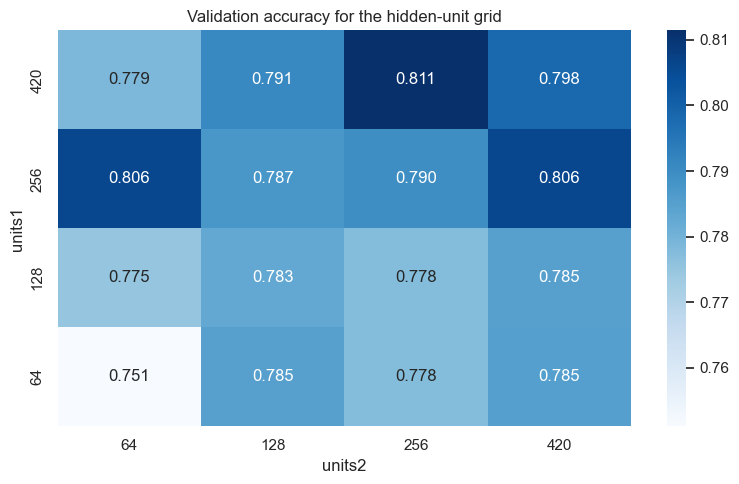

In [4]:
grid_pivot = grid_df.pivot(index='units1', columns='units2', values='final_valid_acc').sort_index(ascending=False)
ax = sns.heatmap(
    grid_pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    vmin=grid_df['final_valid_acc'].min(),
    vmax=grid_df['final_valid_acc'].max(),
)
ax.set_title('Validation accuracy for the hidden-unit grid')
ax.set_xlabel('units2')
ax.set_ylabel('units1')
plt.tight_layout()
plt.show()


## Follow-up runs

After the grid search I test the strongest region again with a few more targeted ideas:

- more epochs to see whether training longer helps more than changing architecture
- a deeper network to test whether extra depth adds useful capacity
- different optimizers to compare the update rule
- batch-size and learning-rate variants to check whether the best region stays stable

This second stage is smaller than a full Cartesian grid, but it gives me more options to compare without making the notebook too heavy.


In [5]:
best_grid = grid_df.sort_values('final_valid_acc', ascending=False).iloc[0].to_dict()
print('Best grid row:', best_grid)

followup_specs = [
    {
        'run_type': 'followup_epochs_7',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': int(best_grid['depth']),
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'epochs': 7,
        'batchsize': 64,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_adamw_42',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': int(best_grid['depth']),
        'optimizer_name': 'adamw',
        'lr': 4.2e-4,
        'epochs': 5,
        'batchsize': 64,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_rmsprop_67',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': int(best_grid['depth']),
        'optimizer_name': 'rmsprop',
        'lr': 6.7e-4,
        'epochs': 5,
        'batchsize': 64,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_depth3',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': 3,
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'epochs': 5,
        'batchsize': 64,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_batch42',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': int(best_grid['depth']),
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'epochs': 5,
        'batchsize': 42,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_batch67',
        'units1': int(best_grid['units1']),
        'units2': int(best_grid['units2']),
        'depth': int(best_grid['depth']),
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'epochs': 5,
        'batchsize': 67,
        'train_steps': 60,
        'valid_steps': 30,
    },
    {
        'run_type': 'followup_420x256',
        'units1': 420,
        'units2': 256,
        'depth': 2,
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'epochs': 5,
        'batchsize': 64,
        'train_steps': 60,
        'valid_steps': 30,
    },
]

print('Follow-up menu:')
display(
    pd.DataFrame(followup_specs)[['run_type', 'units1', 'units2', 'depth', 'optimizer_name', 'lr', 'epochs', 'batchsize']]
)

followup_rows = []
for spec in followup_specs:
    followup_rows.append(run_experiment(**spec))

followup_df = pd.DataFrame(followup_rows).sort_values('final_valid_acc', ascending=False).reset_index(drop=True)
followup_df


Best grid row: {'run_type': 'grid', 'units1': 420, 'units2': 256, 'depth': 2, 'optimizer': 'adam', 'lr': 0.001, 'epochs': 3, 'batchsize': 64, 'train_steps': 60, 'valid_steps': 30, 'capacity_proxy': 676, 'final_valid_acc': 0.8114583333333333, 'best_valid_acc': 0.8114583333333333}
Follow-up menu:


,run_type,units1,units2,depth,optimizer_name,lr,epochs,batchsize
0,followup_epochs_7,420,256,2,adam,0.00100,7,64
1,followup_adamw_42,420,256,2,adamw,0.00042,5,64
2,followup_rmsprop_67,420,256,2,rmsprop,0.00067,5,64
3,followup_depth3,420,256,3,adam,0.00100,5,64
4,followup_batch42,420,256,2,adam,0.00100,5,42
5,followup_batch67,420,256,2,adam,0.00100,5,67
6,followup_420x256,420,256,2,adam,0.00100,5,64


followup_epochs_7: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=1/7, valid_acc=0.7589


followup_epochs_7: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=2/7, valid_acc=0.8130


followup_epochs_7: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=3/7, valid_acc=0.7844


...

followup_420x256: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=2/5, valid_acc=0.7526


followup_420x256: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=3/5, valid_acc=0.7943


followup_420x256: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=4/5, valid_acc=0.8115


followup_420x256: units1=420, units2=256, depth=2, opt=adam, lr=0.001, batchsize=64, epoch=5/5, valid_acc=0.8219


,run_type,units1,units2,depth,optimizer,lr,epochs,batchsize,train_steps,valid_steps,capacity_proxy,final_valid_acc,best_valid_acc
0,followup_epochs_7,420,256,2,adam,0.00100,7,64,60,30,676,0.822396,0.834375
1,followup_420x256,420,256,2,adam,0.00100,5,64,60,30,676,0.821875,0.821875
2,followup_rmsprop_67,420,256,2,rmsprop,0.00067,5,64,60,30,676,0.819271,0.819271
3,followup_batch67,420,256,2,adam,0.00100,5,67,60,30,676,0.810945,0.810945
4,followup_batch42,420,256,2,adam,0.00100,5,42,60,30,676,0.809524,0.811905
5,followup_depth3,420,256,3,adam,0.00100,5,64,60,30,932,0.804167,0.822396
6,followup_adamw_42,420,256,2,adamw,0.00042,5,64,60,30,676,0.799479,0.799479


Top results:


,run_type,units1,units2,depth,optimizer,lr,epochs,batchsize,final_valid_acc
0,followup_epochs_7,420,256,2,adam,0.00100,7,64,0.822396
1,followup_420x256,420,256,2,adam,0.00100,5,64,0.821875
2,followup_rmsprop_67,420,256,2,rmsprop,0.00067,5,64,0.819271
3,grid,420,256,2,adam,0.00100,3,64,0.811458
4,followup_batch67,420,256,2,adam,0.00100,5,67,0.810945
5,followup_batch42,420,256,2,adam,0.00100,5,42,0.809524
6,grid,256,64,2,adam,0.00100,3,64,0.806250
7,grid,256,420,2,adam,0.00100,3,64,0.806250
8,followup_depth3,420,256,3,adam,0.00100,5,64,0.804167
9,followup_adamw_42,420,256,2,adamw,0.00042,5,64,0.799479


Results saved to C:\Users\TEST\Documents\Projects\Study\HAN\Semester 3\portfolio\han-mads-portfolio\1-hypertuning-gridsearch\results.csv
Best final validation accuracy: 0.8224


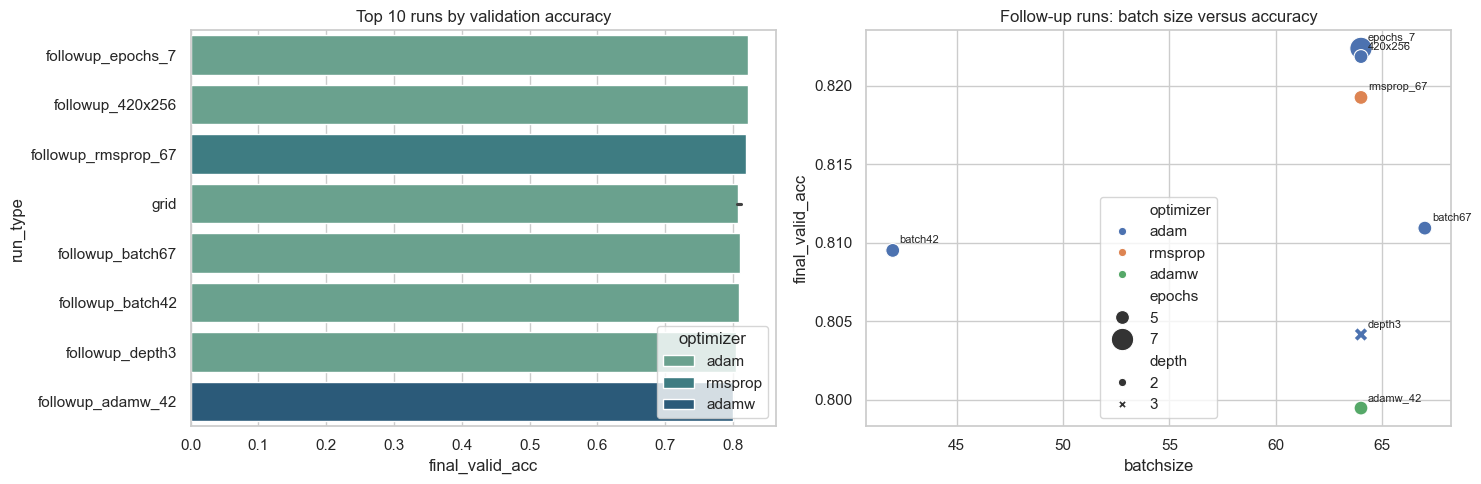

In [6]:
results_df = pd.concat([grid_df, followup_df], ignore_index=True)
results_df = results_df.sort_values('final_valid_acc', ascending=False).reset_index(drop=True)
results_df.to_csv(output_path, index=False)

print('Top results:')
display(results_df[['run_type', 'units1', 'units2', 'depth', 'optimizer', 'lr', 'epochs', 'batchsize', 'final_valid_acc']].head(10))
print(f'Results saved to {output_path.resolve()}')
print(f'Best final validation accuracy: {results_df.iloc[0]["final_valid_acc"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_runs = results_df.head(10).copy()
sns.barplot(
    data=top_runs,
    x='final_valid_acc',
    y='run_type',
    hue='optimizer',
    dodge=False,
    palette='crest',
    ax=axes[0],
)
axes[0].set_title('Top 10 runs by validation accuracy')
axes[0].set_xlabel('final_valid_acc')
axes[0].set_ylabel('run_type')
axes[0].legend(title='optimizer', loc='lower right')

followup_plot_df = followup_df.copy()
sns.scatterplot(
    data=followup_plot_df,
    x='batchsize',
    y='final_valid_acc',
    hue='optimizer',
    style='depth',
    size='epochs',
    sizes=(100, 260),
    palette='deep',
    ax=axes[1],
)
for _, row in followup_plot_df.iterrows():
    axes[1].annotate(
        row['run_type'].replace('followup_', ''),
        (row['batchsize'], row['final_valid_acc']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
    )
axes[1].set_title('Follow-up runs: batch size versus accuracy')
axes[1].set_xlabel('batchsize')
axes[1].set_ylabel('final_valid_acc')

plt.tight_layout()
plt.show()


## Conclusion

The strongest grid result came from the widest two-layer setup in the first pass, so in this notebook the wider models were clearly the most promising region of the search space. That already suggests that, for this dense Fashion-MNIST baseline, adding width helped more than staying with the smaller hidden layers.

The best overall run kept that wide two-layer direction with Adam and `7` epochs, which reached about `82.24%` final validation accuracy. That makes the main lesson fairly clear: once a good width configuration is found, training longer was more useful than adding another layer. The follow-up settings supported the same overall conclusion instead of replacing it.


## Focused long grid search

The earlier overnight search was useful as a broad pass, but it mixed short epoch budgets with a loose search space. The focused long search below keeps that legacy space as a reference, then runs a smaller powers-of-two search for longer training. It writes to a separate CSV so the old exploratory results stay untouched.


In [ ]:
RUN_OVERNIGHT_GRIDSEARCH = False
OVERNIGHT_RESULTS_PATH = Path("results_focused_long.csv")
FOCUSED_LONG_EPOCHS = 30
FOCUSED_LONG_TRAIN_STEPS = 240
FOCUSED_LONG_VALID_STEPS = 80

# Legacy exploratory space kept for reference. It produced results_overnight.csv,
# but it is too broad for the final long comparison.
legacy_overnight_search_space = {
    "units1": [32, 64, 128, 256, 420, 512, 768, 1024],
    "units2": [32, 64, 128, 256, 420, 512],
    "depth": [2, 3, 4],
    "optimizer": ["adam", "adamw", "rmsprop", "sgd"],
    "lr": [1e-4, 3e-4, 6.7e-4, 1e-3, 1.5e-3],
    "batchsize": [32, 42, 64, 67, 96, 128],
    "epochs": [5, 8, 12],
}
LEGACY_MAX_OVERNIGHT_RUNS = 180

focused_architecture_pairs = [
    (256, 128),
    (256, 256),
    (512, 128),
    (512, 256),
    (512, 512),
    (1024, 256),
]

focused_long_search_space = {
    "architecture": focused_architecture_pairs,
    "depth": [2, 4],
    "optimizer": ["adam", "adamw"],
    "lr": [1e-3, 1.5e-3],
    "batchsize": [64, 128],
    "epochs": [FOCUSED_LONG_EPOCHS],
}

overnight_candidates = [
    {
        "units1": units1,
        "units2": units2,
        "depth": depth,
        "optimizer": optimizer,
        "lr": lr,
        "batchsize": batchsize,
        "epochs": epochs,
    }
    for (units1, units2), depth, optimizer, lr, batchsize, epochs in product(
        focused_long_search_space["architecture"],
        focused_long_search_space["depth"],
        focused_long_search_space["optimizer"],
        focused_long_search_space["lr"],
        focused_long_search_space["batchsize"],
        focused_long_search_space["epochs"],
    )
]

print(f"Prepared {len(overnight_candidates)} focused long candidates.")
print(f"Each run uses {FOCUSED_LONG_EPOCHS} epochs and {FOCUSED_LONG_TRAIN_STEPS} train steps per epoch.")
pd.DataFrame(overnight_candidates).head(20)


In [ ]:
if RUN_OVERNIGHT_GRIDSEARCH:
    completed = pd.DataFrame()
    if OVERNIGHT_RESULTS_PATH.exists():
        completed = pd.read_csv(OVERNIGHT_RESULTS_PATH)

    completed_keys = set()
    if not completed.empty:
        completed_keys = set(
            zip(
                completed["units1"],
                completed["units2"],
                completed["depth"],
                completed["optimizer"],
                completed["lr"],
                completed["batchsize"],
                completed["epochs"],
            )
        )

    new_records = []
    for candidate in overnight_candidates:
        key = (
            candidate["units1"],
            candidate["units2"],
            candidate["depth"],
            candidate["optimizer"],
            candidate["lr"],
            candidate["batchsize"],
            candidate["epochs"],
        )
        if key in completed_keys:
            continue

        record = run_experiment(
            run_type="focused_long_grid",
            units1=candidate["units1"],
            units2=candidate["units2"],
            depth=candidate["depth"],
            optimizer_name=candidate["optimizer"],
            lr=candidate["lr"],
            epochs=candidate["epochs"],
            train_steps=FOCUSED_LONG_TRAIN_STEPS,
            valid_steps=FOCUSED_LONG_VALID_STEPS,
            batchsize=candidate["batchsize"],
        )
        new_records.append(record)

        partial = pd.concat([completed, pd.DataFrame(new_records)], ignore_index=True)
        partial = partial.sort_values("final_valid_acc", ascending=False).reset_index(drop=True)
        partial.to_csv(OVERNIGHT_RESULTS_PATH, index=False)

    focused_long_results_df = pd.read_csv(OVERNIGHT_RESULTS_PATH).sort_values("final_valid_acc", ascending=False)
    display(focused_long_results_df.head(20))
else:
    print("Set RUN_OVERNIGHT_GRIDSEARCH = True to run the focused long grid search.")
    print(f"Prepared {len(overnight_candidates)} focused long candidates.")
    print(f"Results will be written to {OVERNIGHT_RESULTS_PATH}.")
